<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


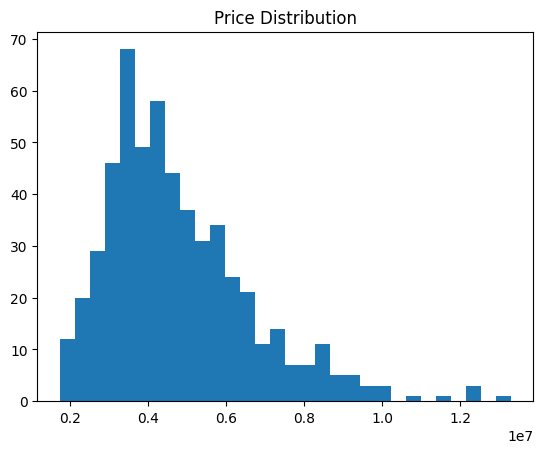

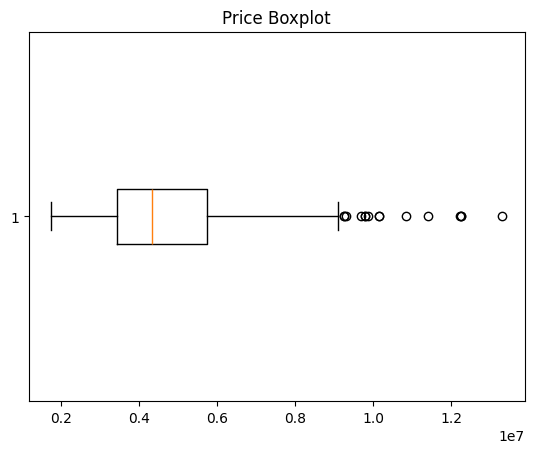

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Housing.csv")

# Basic inspection
df.shape, df.head()

df.info()

df.describe()

missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.sort_values(ascending=False)

plt.hist(df['price'], bins=30)
plt.title("Price Distribution")
plt.show()

plt.boxplot(df['price'], vert=False)
plt.title("Price Boxplot")
plt.show()


def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

lower, upper = detect_outliers_iqr(df['price'])

df['price_outlier'] = np.where(
    (df['price'] < lower) | (df['price'] > upper), 1, 0
)

df['price_outlier'].value_counts()


df['price_outlier']

df['price_capped'] = np.where(
    df['price'] > upper, upper,
    np.where(df['price'] < lower, lower, df['price'])
)

corr = df.corr(numeric_only=True)

corr['price'].sort_values(ascending=False)

df.to_csv("cleaned_dataset.csv", index=False)
